In [92]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt
from scipy.optimize import minimize #what is this?
from scipy.stats import skew, kurtosis, shapiro
import seaborn as sns

In [93]:
#grabbing different assets with low correlation for a diversified portfolio
tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [94]:
#most recent date
end_date = dt.datetime.today()
print(end_date)

2025-07-24 15:10:20.302733


In [95]:
#start date (5 years ago)
start_date = end_date - dt.timedelta(days=5*365)
print(start_date)

2020-07-25 15:10:20.302733


In [96]:
#download for each ticker
adj_close_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    adj_close_df[ticker] = data['Adj Close']

print(adj_close_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                   SPY        BND         GLD         QQQ         VTI
Date                                                                 
2020-07-27  300.955994  77.116646  182.229996  252.588196  152.531845
2020-07-28  299.047241  77.151276  183.750000  249.373993  151.416412
2020-07-29  302.725159  77.272438  185.130005  252.248276  153.424255
2020-07-30  301.645050  77.315674  183.759995  253.569000  153.080292
2020-07-31  304.028625  77.419510  185.429993  258.093933  153.861160
...                ...        ...         ...         ...         ...
2025-07-17  628.039978  72.730003  307.589996  561.799988  309.260010
2025-07-18  627.580017  72.849998  308.390015  561.260010  309.089996
2025-07-21  628.770020  73.059998  313.130005  564.169983  309.440002
2025-07-22  628.859985  73.180000  316.100006  561.250000  309.799988
2025-07-23  634.210022  73.029999  312.179993  563.809998  312.410004

[1254 rows x 5 columns]


In [9]:
#changing to lognormal returns due to their additive property - look this up later!!
log_returns  = np.log(adj_close_df / adj_close_df.shift(1))

In [10]:
#drop any values
log_returns = log_returns.dropna()

In [11]:
print(log_returns)

                 SPY       BND       GLD       QQQ       VTI
Date                                                        
2020-07-28 -0.006362  0.000449  0.008307 -0.012807 -0.007340
2020-07-29  0.012224  0.001569  0.007482  0.011460  0.013173
2020-07-30 -0.003575  0.000560 -0.007428  0.005222 -0.002244
2020-07-31  0.007871  0.001343  0.009047  0.017688  0.005088
2020-08-03  0.006928 -0.000348  0.001132  0.013416  0.008662
...              ...       ...       ...       ...       ...
2025-07-17  0.006101  0.000275 -0.002176  0.008060  0.006488
2025-07-18 -0.000733  0.001649  0.002598 -0.000962 -0.000550
2025-07-21  0.001894  0.002878  0.015253  0.005171  0.001132
2025-07-22  0.000143  0.001641  0.009440 -0.005189  0.001163
2025-07-23  0.008472 -0.002052 -0.012479  0.004551  0.008390

[1253 rows x 5 columns]


ShapiroResult(statistic=np.float64(0.9883858688871398), pvalue=np.float64(2.0130376840405804e-08))


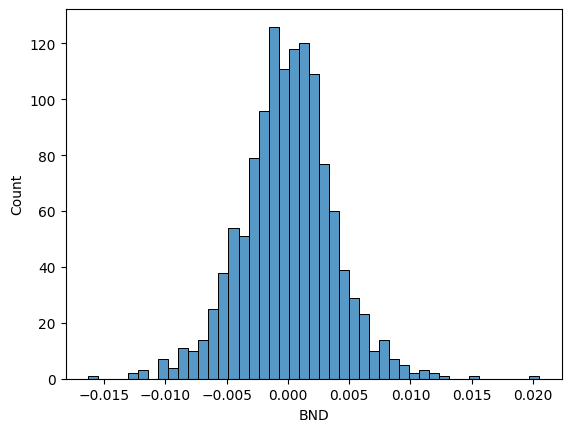

In [104]:
#looking at the distribution and its tails
#testing for normality - parametric or nonparametric test?
returns = log_returns['BND']
sns.histplot(returns)

#running Shapiro-Wilk test for normality
#This is a hypotheses test and the two hypotheses are as follows:

#Ho(Accepted): Sample is from the normal distributions.(Po>0.05)
#Ha(Rejected): Sample is not from the normal distributions.

shapiro_results = shapiro(returns)
print(shapiro_results)

#all returns are normally distributed (parametric)

In [12]:
#Calculate the covariance matrix
#This is how we are measuring the risk of the portfolio

cov_matrix = log_returns.cov()*252

In [13]:
print(cov_matrix)

          SPY       BND       GLD       QQQ       VTI
SPY  0.030627  0.001947  0.003742  0.038346  0.031103
BND  0.001947  0.003577  0.003121  0.002789  0.002038
GLD  0.003742  0.003121  0.023784  0.005011  0.003893
QQQ  0.038346  0.002789  0.005011  0.054502  0.039017
VTI  0.031103  0.002038  0.003893  0.039017  0.031920


In [14]:
#Defining Portfolio Metrics
#calculate the standard deviation
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)


In [15]:
#calculating expected return of the portfolio (prob * weight)
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean()*weights)*252

In [16]:
#calclate the sharpe ratio
def sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return (expected_return(weights, log_returns)-risk_free_rate) / standard_deviation(weights, cov_matrix)

In [17]:
#how to get an accurate risk free rate?
#get fed's API
from fredapi import Fred

fred = Fred(api_key='c8a1a5229b19f852a4047fbc565554a7')

#GS10?? current treasury rate??
ten_year_treasury_rate = fred.get_series_latest_release('GS10')/100

risk_free_rate = ten_year_treasury_rate.iloc[-1]
print(risk_free_rate)

0.0438


In [18]:
#negative sharpe ratio
def neg_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

In [19]:
#SETTING CONSTRAINTS AND BOUNDS

In [20]:
#set the constraints and bounds. Making sure weights equal to 1
#bounds - upper and lower. 0 lower, 0.5 upper
#0 means cant sell, 0.5 means we cant have anything over 50%

#({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}) 
#type: eq means equality, fun: means taking the array of portfolio weights as input and ensures all the weights equal to 1.
constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})
bounds = [(0, 0.5) for _ in range(len(tickers))]

In [21]:
#set intital weights
initial_weights = np.array([1/len(tickers)]*(len(tickers)))
print(initial_weights)

#SLSQP stands for Sequential Least Squares Quadratic Programming, which is a numerical optimization technique suitable for solving nonlinear optimization problems with constraints.
#optimize the weights to maximize sharpe ratio but minimizing each weights needed that equal to 1
optimized_results = minimize(neg_sharpe_ratio, initial_weights, args=(log_returns, cov_matrix, risk_free_rate), method='SLSQP', constraints=constraints, bounds=bounds)

[0.2 0.2 0.2 0.2 0.2]


In [22]:
optimal_weights = optimized_results.x

print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = expected_return(optimal_weights, log_returns)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, risk_free_rate)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Expected Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
SPY: 0.5000
BND: 0.0000
GLD: 0.4405
QQQ: 0.0000
VTI: 0.0595
Expected Annual Return: 0.1312
Expected Volatility: 0.1268
Sharpe Ratio: 0.6893


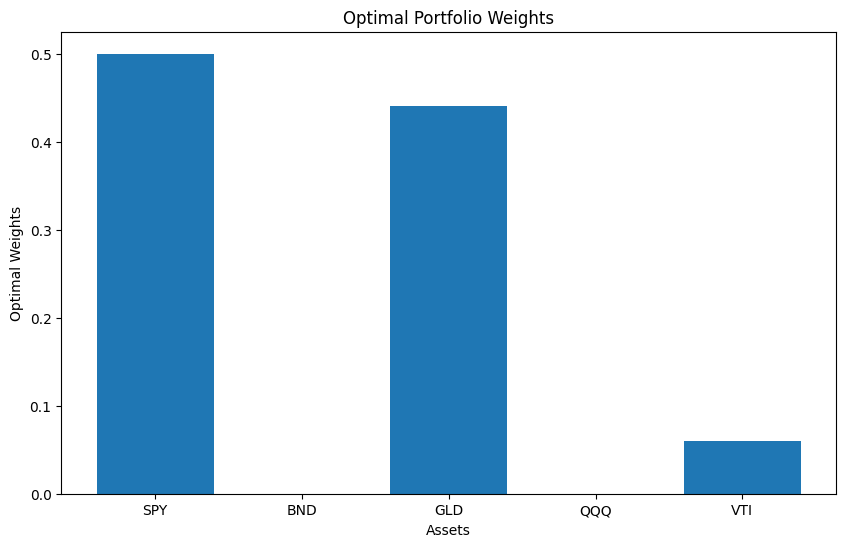

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights)

plt.xlabel('Assets')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')

plt.show()